<h2>Suffix Tries</h2>
We will present some notes and implementations of Suffix Tries. We will work directly with so-called "compressed tries". What we are describing in these notes is often called a generalized suffix trie.
This presentation is going to be somewhat sketchy. While the ideas are quite intuitive, the devil (as they say) is in the details. The details are hard to describe fully and reading the code should give you a great idea. I sourced my presentation from two sources:

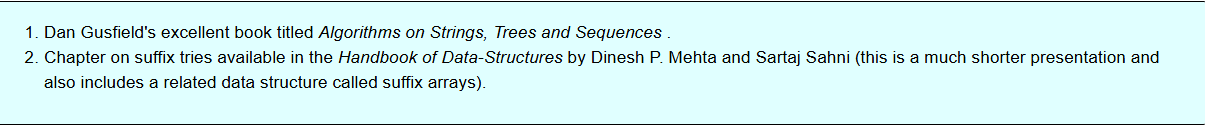

A suffix trie is a trie data structure whose set of strings correspond to all the suffixes of a given string. As an example, consider the string mamamia$ wherein "$" represents the special termination character that only appears at the end of the string.

The suffixes are {mamamia$, amamia$, mamia$, amia$, mia$,ia$,a$,$}

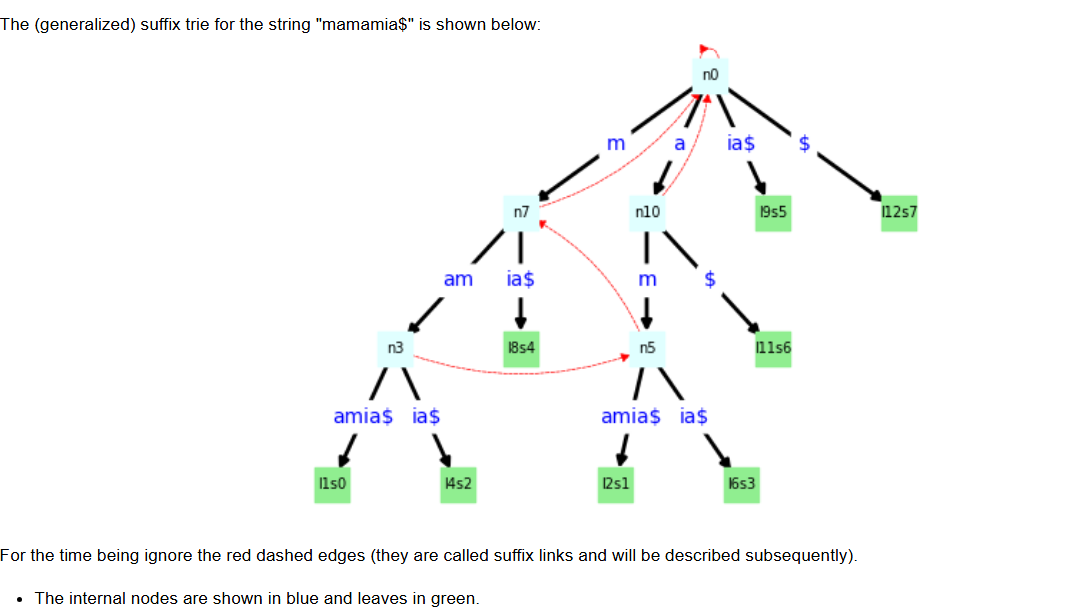

Each path from the root to leaf corrresponds to a suffix of the string (see set above) and every suffix belongs to precisely one path. Each leaf is labeled "lisj" for two numbers  𝑖,𝑗 wherein  𝑖 denotes the ID and  𝑗 denotes the starting position of the suffix that the leaf represents.
Note that the edges are "compressed": each edge is labeled by a substring of the original string rather than by a single character (in the case of a regular trie). Also for every internal node, no two outgoing edges represent strings beginning with the same character.

herefore, for any string, there is either a unique path in the suffix trie starting from the root, or no path at all. Returning to the "mamamia$" example above,

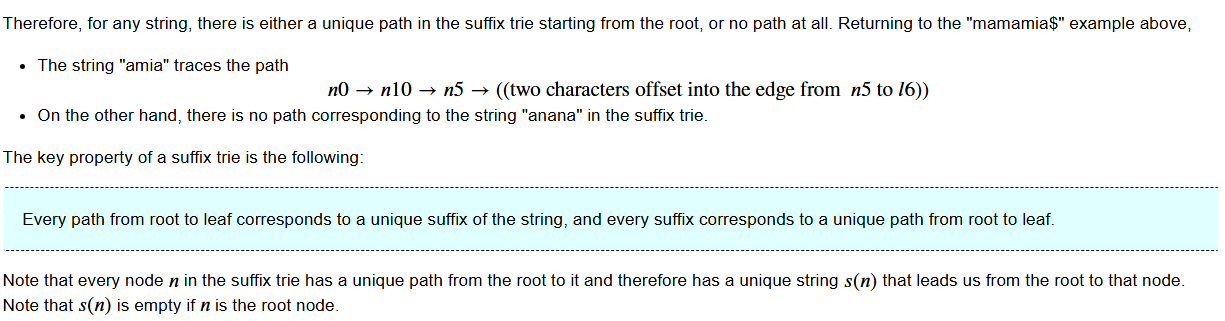

Every node in suffix trie has unique path from root s(n)

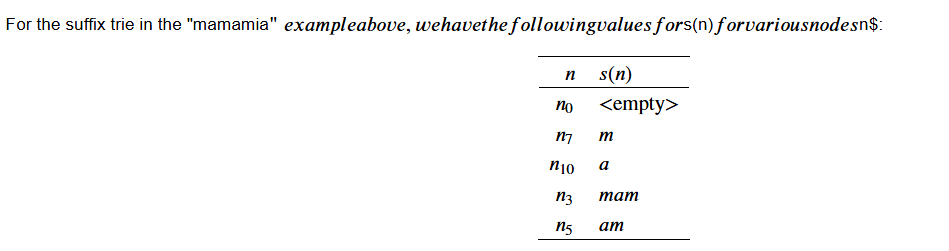

<h2>Suffix links</h2>

Suffix links are a useful short cut between nodes in the trees. Let  𝑛 be an internal node where  𝑠(𝑛)=𝑐𝛼  where  𝑐  is a character and  𝛼 is a substring. The suffix link is an edge of the form  𝑛→𝑚, such that  𝑠(𝑚)=𝛼. 

self-note - if current path is c->a->t we are considering prefix for 't', then longest prefix that is not current string is a->t and we know there is another root->a->t exists and hence suffix link points to this other 't'. If no such suffix exists then suffix_link of 't' would have pointed to root(?)

We will set the suffix link for the root to be itself by convention. 
self-note - suffix link of immediate children of root points to root

For the suffix trie in the "mamamia$" example above, the suffix links are shown as red dashed lines.

However, the key question is that why does a suffix link for a node need to point to another node. Could it not be possible that the suffix link for a node point to somewere in the middle of the string that labels an edge.

Thoerem - <u> Let  𝑛 be an internal node such that  𝑠(𝑛)=𝑐𝛼. There must be an internal node  𝑚 in the suffix trie such that  𝑠(𝑚) =𝛼. </u>

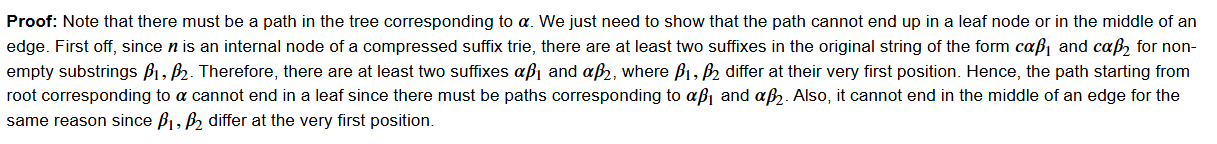

<h4>Implementation</h4>

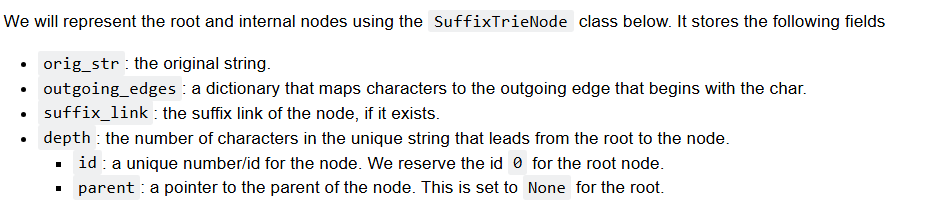



In [ ]:
class SuffixTrieNode:
    
    def __init__(self, node_id, orig_str):
        self.orig_str = orig_str # a reference to the entire string
        self.outgoing_edges = {} # dictionary from chars to edges
        self.suffix_link = None  # suffix link : initially set to None
        self.id = node_id # Note: id == 0 is taken to be root for now.
        self.depth = 0 # automatically set the depth when node's parent is set
        self.parent = None # parent pointer
        
    def is_root(self):
        return self.id == 0
        
    def get_edge(self, char):
        if char in self.outgoing_edges:
            return self.outgoing_edges[char]
        else:
            return None
        
    def is_leaf(self):
        return False
    
    def add_suffix_link(self, node):
        self.suffix_link = node
        
    def add_outgoing_edge(self, new_edge):
        edge_init_char = new_edge.get_char_at(0)
        # ensure that an edge with the initial character does not exist
        assert edge_init_char not in self.outgoing_edges, f"Char {edge_init_char} already has an outgoing edge for node id:{self.id}"
        #ensure that the new_edge src matches self
        assert new_edge.src.id == self.id, f"Src node in outgoing edge id:{new_edge.src.id} does not match node id {self.id}"
        # add the new edge to the dictionary with the initial char as key
        self.outgoing_edges[edge_init_char] = new_edge
        # add a parent pointer from destination to the src of the new edge
        new_edge.dest.parent = new_edge.src # set the parent pointer of the new edges dest
        if not new_edge.is_leaf_edge(): # set the depth of the destination node for the edge
            new_edge.dest.depth = self.depth + new_edge.length()
       
        
    def find_edge_corresponding_to_child(self, child_node):
        # search among outgoing edges to see if there is one whose destination is the child node
        for (_, edge) in self.outgoing_edges.items():
            if edge.dest.id == child_node.id:
                return edge
        return None # no such edge found
    
        
    

We will use the SuffixTrieLeaf structure to represent leaves of the suffix trie. Leaves will have a field suffix_start_pos that tells us where the suffix for the path from root to leaf starts in the original string.

Going back to the example suffix trie shown above for "mamamia$", we have labeled each leaf (shown in green) as l<id>s<suffix_start_pos> that gives us the starting position of the suffix that corresponds to a given leaf.

In [2]:
class SuffixTrieLeaf:
    def __init__(self, node_id, orig_str, suffix_start_pos):
        self.orig_str = orig_str # the original string
        self.id  = node_id # the id of this node
        assert 0 <= suffix_start_pos < len(orig_str) 
        self.suffix_start_pos = suffix_start_pos # the starting pos for the suffix
        self.parent = None # parent pointer initially set to None
        
    def is_leaf(self):
        return True
    

The SuffixTrieEdge structure repreents an edge. An edge goes from src to dest nodes which can be internal nodes or dest can be a leaf.

Also the edge has two integers lo and hi that refer to positions in the string The edge is taken to represent the substring from positions lo to hi inclusive. Note that hi=-1 represents the end of the string.

In [ ]:
class SuffixTrieEdge:
    
    def __init__(self, orig_str, src_node, dest_node, lo, hi):
        assert 0 <= lo < len(orig_str) # lo must be a valid position in the original string
        # if destination node is a leaf then hi == -1 else hi != -1
        if dest_node.is_leaf():
            assert hi == -1 
        else:
            assert lo <= hi <= len(orig_str)
        assert not src_node.is_leaf() # src node cannot be a leaf.
        # edge represents str[lo]...str[hi] inclusive if hi != -1
        # or set[lo] ... str[end]
        self.orig_str = orig_str # set the orig_str field
        self.lo = lo # set lo/hi
        self.hi = hi 
        self.src = src_node # set src/dest
        self.dest = dest_node
        
    def is_leaf_edge(self):
        return self.hi == -1
    
    def length(self):
        if self.hi == -1:
            return -1
        else:
            return self.hi - self.lo + 1
    
    def get_char_at(self, offs):
        assert self.hi == -1 or offs + self.lo <= self.hi
        return self.orig_str[self.lo + offs]
    
    
    def get_sub_str(self, end=-1):
        if self.hi == -1:
            return self.orig_str[self.lo:end] if (end != -1) else self.orig_str[self.lo:]
        
        else:
            return self.orig_str[self.lo:self.hi+1]
        
        
    def reset_hi_and_dest(self, new_dest, new_hi):
        assert new_hi >= self.lo, f"Cannot replace hi value by {new_hi}"
        assert not new_dest.is_leaf(), "Cannot replace destination by a leaf node"
        self.hi = new_hi
        new_dest.parent = self.src
        new_dest.depth = self.src.depth + self.length()
        self.dest = new_dest
        
    
    
        
        

As a convenience, we will define a structure called an TrieAddress to refer to locations within a suffix trie. A trie address can be of two types:
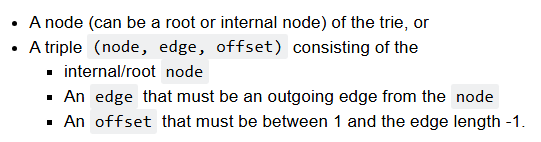

An address helps is point to a location in the trie that can be at a node or somewhere in the "middle" of an edge.
As an example TrieAddress(n7, n7 -> n3, 1) refers to a pointer that points to after the character a in the edge labled am from n7 to n3.

Likewise TrieAddress(n7, None, 0) points to the internal node n7. If the suffix trie were actually a "full trie" with each edge labeled by a single character rather than a compressed trie (wherein each edge can be labeled by an arbitrary substring), a trie address would simply have pointed to a node of the full trie.

The trie address class implements three critical helper methods:

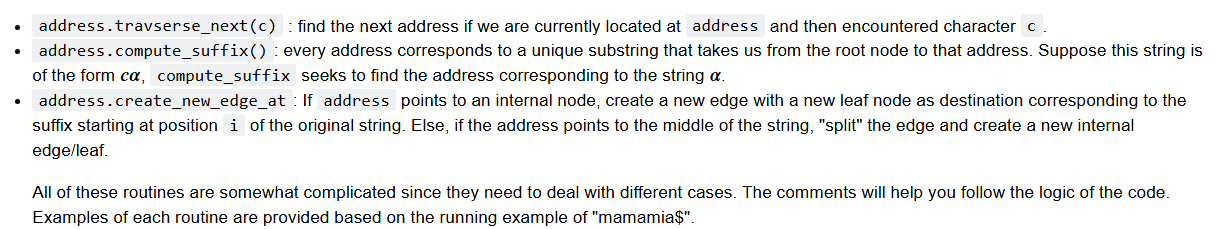


In [4]:
class TrieAddress:
    
    def __init__(self,  node, edge=None, offs=0):
        assert 0 <= offs 
        self.node = node # set the node
        self.edge = edge # set the edge
        self.offs = offs # set the offset
        if self.edge != None:
            assert self.offs > 0
        else:
            assert self.offs == 0
    
    def traverse_next(self, c):
        """Function traverse_next: find the next address (if one exists) that 
           is obtained when we encounter character c. Return the new address if 
           one exists or else return None."""
        if self.edge == None: # Is the address pointing to an internal node?
            # Yes: address is just a pointer to an internal node/root.
            # check if the node has an outgoing edge corresponding to 'c'
            new_edge = self.node.get_edge(c) # try to get a new edge corresponding to character `c`.
            if new_edge == None:
                return None # No such edge, then return None
            else: # new_edge != None
                assert new_edge.get_char_at(0) == c # got an edge. Check that we got the right one.
                if new_edge.is_leaf_edge() or new_edge.length() > 1: # if new edge is a leaf edge, or its length is more than 2
                    return TrieAddress( self.node, new_edge,  1 ) # return an address with an offset of 1 into the new edge
                else:
                    new_node = new_edge.dest # new edge is not a leaf and must have length exactly one
                    return TrieAddress( new_node, None, 0) # the address must therefore be the destination.
        else: # self.edge != None
            # No: address is a pointer self.offs past self.node along self.edge
            edge = self.edge 
            if edge.lo + self.offs < len(edge.orig_str) and edge.get_char_at(self.offs) == c:# if the next char is a `c`
                if edge.is_leaf_edge() or self.offs < edge.length() -1 : # is the edge a leaf edge or do we have one more char in the edge?
                    return TrieAddress(self.node, self.edge, self.offs+1) # return a new address that is just one further offset along same edge
                else:
                    dest_node = edge.dest # we reaches the destination node
                    return TrieAddress( dest_node, None, 0) # return the new address
            else: # next char is not a `c`
                return None # no next address
            
    def compute_suffix(self, debug=False):
        # to compute a suffix, follow the suffix link from the source node
        #                      to get to a new source node.
        #                     next, fetch the appropriate edge 
        #                     finally, move offset distance into the edge.
        node = self.node # unpack
        edge = self.edge 
        offs = self.offs 
        if node.id == 0 and offs <= 1: # If we are at the very root, the suffix is the same.
                return TrieAddress(node, None, 0) # let's keep the suffix the same
        if node.id == 0: # if we are the the root, the suffix node is the root
            s_node = node
        else:
            s_node = node.suffix_link # otherwise, follow the suffix link.
            assert s_node != None # assert that the suffix link should exist
        
        if edge == None: # if the address points right to a node, 
            return TrieAddress(s_node, None, offs) # the suffix address points right to the suffix node.
        
        if node.id == 0: # Are we are at the root.
            c = edge.get_char_at(1) # compute the char c at position 1 of the edge.
            s_edge = node.get_edge(c) # get the outgoing edge for that character c
            assert s_edge != None, f"No edge for char {c} at node {node.id}" # this edge should exist
            offs = offs - 1 # suffix is offs -1 length along s_edge
            fwd = 1 # set the fwd pointer to 1 to indicate that we have moved one step fwd
            if debug:
                print(f"Debug: Looking for {offs} past {s_edge.src.id, s_edge.dest.id}")
        else:
            c = edge.get_char_at(0) # get the initial char at the edge
            s_edge = s_node.get_edge(c) # get the corresponding edge at the suffix link
            fwd = 0
            assert s_edge != None, f"No edge for char {c} at node {s_node.id}"
            if debug:
                print(f"Debug: Looking for {offs} past {s_edge.src.id, s_edge.dest.id}")

        assert s_edge != None # assert that the edge should exist
         # Now we have to find the location that is offs steps away from s_node 
         # along s_edge. 
        if s_edge.is_leaf_edge() or offs < s_edge.length(): 
            # if the edge is leaf or the offset is less than the length
            return TrieAddress(s_node, s_edge, offs) # we found the required suffix address along s_edge itself
        else:
            new_offs = offs # otherwise, move offset distance away from edge
            # we may have to move across multiple nodes/edges to find the location 
            # that is offs away from node s_node.
            while (not s_edge.is_leaf_edge()) and new_offs >= s_edge.length():
                new_offs = new_offs - s_edge.length() # move forward edge length from s
                fwd = fwd + s_edge.length()
                s_node = s_edge.dest # get the destination node
                if new_offs > 0:
                    c = edge.get_char_at(fwd) # get the edge corresponding to the character
                    s_edge = s_node.get_edge(c)
                    assert s_edge != None
                else:
                    break
            if new_offs > 0:
                return TrieAddress(s_node, s_edge, new_offs)
            else:
                return TrieAddress(s_node, None, 0)

    def create_new_edge_at(self, orig_str, i, node_id):
        """Create a new leaf edge in the suffix trie by 
           inserting the char at orig_str[i]. """
        assert i >= 0 and i < len(orig_str) # i better be a valid index into orig_str
        c = orig_str[i]  # fetch the char
        node = self.node # unpack 
        edge = self.edge 
        offs = self.offs
        if edge == None: # if the current address points to an internal node
            assert offs == 0
            assert node.get_edge(orig_str[i]) == None, f"Node {node.id} already has outgoing edge for {orig_str[i]}"
            new_leaf = SuffixTrieLeaf(node_id, orig_str, i - node.depth) # create a new leaf node to be the destination
            new_edge = SuffixTrieEdge(orig_str, node, new_leaf, i, -1) # create a leaf edge with 
            node.add_outgoing_edge(new_edge) # add it to the node pointed by the current address
            return (node, new_leaf, False) # return the node at which insertion happend, the new leaf and whether or not a new internal node was created
        else:
            assert edge.get_char_at(offs) != c, f'{edge.get_char_at(offs)}, {c}' # if the next char is c, we should not be calling this function
            # split edge into two
            node1 = SuffixTrieNode(node_id, orig_str) # create a new node       
            src_node = edge.src 
            dest_node = edge.dest 
            lo = edge.lo
            hi = edge.hi
            # modify the current edge to make node1 its destination and the 
            # value of hi to be lo. +offs -1 
            edge.reset_hi_and_dest(node1, lo+offs-1)
            # create two new edges 
            # first one consists of the remaining part of edge
            new_edge_1 = SuffixTrieEdge(orig_str, node1, dest_node, lo+offs, hi)
            node1.add_outgoing_edge(new_edge_1)
            suffix_start_pos = i - node1.depth
            # create a new leaf node 
            new_leaf = SuffixTrieLeaf(node_id+1, orig_str, suffix_start_pos)
            # create a new leaf edge 
            new_edge_2 = SuffixTrieEdge(orig_str, node1, new_leaf, i, -1)
            node1.add_outgoing_edge(new_edge_2)
            return (node1, new_leaf, True) # return newly created internal node and new leaf, True indicates that the internal node we are returning is newly created
            
    def is_at_root(self):
        return self.node.id == 0 and self.offs == 0
            
    def compute_depth(self):
        if self.edge == None:
            return self.node.depth
        else:
            return self.node.depth + self.offs 
    
    def __str__(self):
        edge = self.edge
        return f'{self.node.id}, {(edge.src.id, edge.dest.id) if edge != None else None}, {self.offs}'
                

In [10]:

try:
    import networkx
except:
    !pip3 install networkx
    import networkx

try:
    import matplotlib
except:
    !pip3 install matplotlib
    import matplotlib

try:
    import pygraphviz
except:
    !pip3 install pygraphviz
    import pygraphviz



Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Failed to build pygraphviz


  error: subprocess-exited-with-error
  
  × Building wheel for pygraphviz (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [48 lines of output]
      running bdist_wheel
      running build
      running build_py
      creating build\lib.win-amd64-cpython-312\pygraphviz
      copying pygraphviz\agraph.py -> build\lib.win-amd64-cpython-312\pygraphviz
      copying pygraphviz\graphviz.py -> build\lib.win-amd64-cpython-312\pygraphviz
      copying pygraphviz\scraper.py -> build\lib.win-amd64-cpython-312\pygraphviz
      copying pygraphviz\testing.py -> build\lib.win-amd64-cpython-312\pygraphviz
      copying pygraphviz\__init__.py -> build\lib.win-amd64-cpython-312\pygraphviz
      creating build\lib.win-amd64-cpython-312\pygraphviz\tests
      copying pygraphviz\tests\test_attribute_defaults.py -> build\lib.win-amd64-cpython-312\pygraphviz\tests
      copying pygraphviz\tests\test_clear.py -> build\lib.win-amd64-cpython-312\pygraphviz\tests
      copying pygraphviz\test

ModuleNotFoundError: No module named 'pygraphviz'

In [8]:

# very useful routine to draw a suffix trie using networkx package in Python.


import networkx as nx
from matplotlib import pyplot as plt

def draw_networkx_graph(root, end=-1, highlight_addr=None, filename=None):
    worklist = [root]
    node_labels={}
    edge_str_label = {}
    suffix_links = [] 
    leaf_nodes = []
    internal_nodes = []
    G = nx.DiGraph()
    while len(worklist) > 0:
        node = worklist.pop()
        G.add_node(node.id)
        if node.is_leaf():
            leaf_nodes.append(node.id)
            node_labels[node.id]= "l"+str(node.id) + "s"+str(node.suffix_start_pos)
            continue
        else:
            internal_nodes.append(node.id)
            node_labels[node.id]= "n"+str(node.id)
        if node.suffix_link != None:
            suffix_links.append((node.id, node.suffix_link.id))
        for (c, edge) in node.outgoing_edges.items():
            (u, v) = (edge.src.id, edge.dest.id)
            G.add_edge(u, v)
            s = edge.get_sub_str(end)
            edge_str_label[(u,v)] = s
            worklist.append(edge.dest)            
    pos = nx.nx_agraph.graphviz_layout(G, prog="dot")  # positions for all nodes
    fig, ax = plt.subplots()
    fig.set_tight_layout(True)
    nx.draw_networkx_nodes(G, pos=pos, nodelist=internal_nodes,  node_shape="s", node_color="lightcyan")
    nx.draw_networkx_nodes(G, pos=pos, nodelist=leaf_nodes, node_shape="s", node_color="lightgreen")
    nx.draw_networkx_edges(G, pos=pos,width=2.0)
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=7, font_color='k')
    #nx.draw_networkx_edge_labels(G, pos,edge_labels=edge_char_label, font_color='red')
    nx.draw_networkx_edge_labels(G, pos,edge_labels=edge_str_label, font_color='blue', rotate=False)
    nx.draw_networkx_edges(G, pos, width=0.5, edgelist=suffix_links, style='dashed', edge_color='r', connectionstyle='arc3,rad=0.2')
    if highlight_addr != None:
        node = highlight_addr.node 
        edge = highlight_addr.edge
        offs = highlight_addr.offs
        nx.draw_networkx_nodes(G, pos=pos, nodelist=[node.id],  node_shape="s", node_color="yellow")

        if edge != None:
            nx.draw_networkx_edges(G, edgelist=[(edge.src.id, edge.dest.id)], edge_color='b', width=2, pos=pos)
            c = edge.get_char_at(0)
            txt = f'{offs}'
            x0,y0 = pos[node.id]
            x1,y1 = pos[edge.dest.id]
            (x, y) = ((3*x0+x1)/4, (3*y0+y1)/4)
            props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
            plt.text(x-0.5, y+0.5, s=txt,  fontsize=8, bbox=props,horizontalalignment='center')
        
    ax = plt.gca()
    ax.margins(0.20)
    plt.axis("off")
    if filename != None:
        plt.savefig(filename, bbox_inches='tight')
    plt.show()
    
        

In [11]:
## Let's manually construct a test suffix trie for "mamamia$"
orig_str = "mamamia$"

n3 = SuffixTrieNode(3, orig_str)
l31 = SuffixTrieLeaf(5, orig_str, 0)
l32 = SuffixTrieLeaf(6, orig_str, 2)
e31 = SuffixTrieEdge(orig_str, n3, l31, 3, -1)
e32 = SuffixTrieEdge(orig_str, n3, l32, 5, -1)
n3.add_outgoing_edge(e31)
n3.add_outgoing_edge(e32)

n4 = SuffixTrieNode(4, orig_str)

l41 = SuffixTrieLeaf(8, orig_str, 1)
l42 = SuffixTrieLeaf(9, orig_str, 3)
e41 = SuffixTrieEdge(orig_str, n4, l41, 3, -1)
e42 = SuffixTrieEdge(orig_str, n4, l42, 5, -1)
n4.add_outgoing_edge(e41)
n4.add_outgoing_edge(e42)

n1 = SuffixTrieNode(1, orig_str)
l11 = SuffixTrieLeaf(7, orig_str, 4)
e11 = SuffixTrieEdge(orig_str, n1, n3, 1, 2)
e12 = SuffixTrieEdge(orig_str, n1, l11, 5, -1)
n1.add_outgoing_edge(e11)
n1.add_outgoing_edge(e12)


n2 = SuffixTrieNode(2, orig_str)
l21 = SuffixTrieLeaf(10, orig_str, 6)
e21 = SuffixTrieEdge(orig_str, n2, n4, 2, 2)
e22 = SuffixTrieEdge(orig_str, n2, l21, 7, -1)
n2.add_outgoing_edge(e21)
n2.add_outgoing_edge(e22)

root = SuffixTrieNode(0, orig_str)
l11 = SuffixTrieLeaf(11, orig_str, 5)
l12 = SuffixTrieLeaf(12, orig_str, 7)
e01 = SuffixTrieEdge(orig_str, root, n1, 0, 0 )
e02 = SuffixTrieEdge(orig_str, root, n2, 1, 1)
e03 = SuffixTrieEdge(orig_str, root, l11, 5, -1)
e04 = SuffixTrieEdge(orig_str, root, l12, 7,-1)
root.add_outgoing_edge(e01)
root.add_outgoing_edge(e02)
root.add_outgoing_edge(e03)
root.add_outgoing_edge(e04)
root.add_suffix_link(root)
n1.add_suffix_link(root)
n2.add_suffix_link(root)
n3.add_suffix_link(n4)
n4.add_suffix_link(n1)

draw_networkx_graph(root)

ImportError: requires pygraphviz http://pygraphviz.github.io/